# Análisis FNCER

---


**Objetivo.** Presentar un análisis claro y encadenado de la matriz FNCER en Colombia con:

- Limpieza reproducible
- Visualizaciones con **leyendas** y **La Guajira** destacada/separada
- Gráficas **ordenadas** y comentadas
- Serie de proyectos por año **desde 2015**


## 1. Configuración y carga de datos
En esta sección importamos librerías y definimos rutas a los archivos.


In [ ]:

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (8, 6),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False
})


csv_proyectos = "/content/drive/MyDrive/Bootcamp Talentotech2/Final/matriz_energetica_FNCER.csv"
csv_poblacion = "/content/drive/MyDrive/Bootcamp Talentotech2/Final/Datos_DANE.csv"
csv_radiacion = "/content/drive/MyDrive/Bootcamp Talentotech2/Final/radiacion de departamentos con mayor producción - Map data Departamento.csv"


df = pd.read_csv(csv_proyectos)
pop_2023 = pd.read_csv(csv_poblacion, sep=";", names=['DP','DPNOM','ANIO','AREAGE','TOTAL'], header=0)
try:
    df_radiacion = pd.read_csv(csv_radiacion)
except Exception:
    df_radiacion = None

df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Proyecto,Tipo,Capacidad,Departamento,Municipio,Código Departamento,Código Municipio,Fecha estimada FPO,Energía [kWh/día],Usuarios,Inversión estimada [COP],Empleos estimados,Emisiones CO2 [Ton/año]
0,JEPIRACHI,Eólico,18.42,LA GUAJIRA,URIBIA,44,44847,2004-04-27T00:00:00.000,"176,832","30,665","79,206,000,000",51,"51,635"
1,AUTOG CELSIA SOLAR YUMBO,Solar,9.80,VALLE DEL CAUCA,YUMBO,76,76892,2017-03-09T00:00:00.000,"47,040","8,157","42,140,000,000",68,"13,736"
2,CELSIA SOLAR BOLIVAR,Solar,8.06,BOLÍVAR,SANTA ROSA,13,13683,2019-02-01T00:00:00.000,"38,688","6,709","34,658,000,000",56,"11,297"
3,EL PASO SOLAR (ENEL GREEN POWER),Solar,67.00,CESAR,EL PASO,20,20250,2019-04-05T00:00:00.000,"321,600","55,769","288,100,000,000",466,"93,907"
4,SOLAR CASTILLA ECP,Solar,20.00,META,CASTILLA LA NUEVA,50,50150,2019-10-10T00:00:00.000,"96,000","16,647","86,000,000,000",139,"28,032"
5,AGPE TECNOEMPAQUES DE OCCIDENTE,Solar,0.10,VALLE DEL CAUCA,CALI,76,76001,2019-12-19T00:00:00.000,480,83,"430,000,000",1,140
6,RADAR FAC SAN ANDRÉS,Solar,0.01,"ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANT...",SAN ANDRÉS,88,88001,2019-12-30T00:00:00.000,48,8,"43,000,000",0,14
7,AGPE SFV MCDONALDS SOLEDAD,Solar,0.09,ATLÁNTICO,SOLEDAD,8,8758,2020-02-27T00:00:00.000,432,75,"387,000,000",1,126
8,CELSIA SOLAR ESPINAL,Solar,9.90,TOLIMA,ESPINAL,73,73268,2020-05-31T00:00:00.000,"47,520","8,240","42,570,000,000",69,"13,876"
9,FEDERACIÓN NACIONAL DE CAFETEROS,Solar,0.08,TOLIMA,IBAGUÉ,73,73001,2020-09-02T00:00:00.000,384,67,"344,000,000",1,112


## 2. Normalización de campos y tipologías
Convertimos a numérico las columnas con separadores, fijamos datatime, creamos Año FPO y homogenizamos nombres de territorios.


In [ ]:
# Copia de trabajo
df = df.copy()

def _to_float(x):
    # Maneja strings con comas o NaN
    if pd.isna(x):
        return np.nan
    return float(str(x).replace(",", "").strip())

# Campos a numérico
for col in ["Energía [kWh/día]", "Usuarios", "Inversión estimada [COP]", "Empleos estimados", "Emisiones CO2 [Ton/año]"]:
    df[col] = df[col].apply(_to_float)

# Fechas y Año
df["Fecha estimada FPO"] = pd.to_datetime(df["Fecha estimada FPO"], errors="coerce")
df["Año FPO"] = df["Fecha estimada FPO"].dt.year

# Limpieza básica de texto
df["Municipio"] = df["Municipio"].astype(str).str.upper().str.strip()
df["Departamento"] = df["Departamento"].astype(str).str.upper().str.strip()

# Unificación de San Andrés
df["Departamento"] = df["Departamento"].replace(
    {"ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANTA CATALINA": "ARCHIPIÉLAGOS"}
)

df.filter(items=["Proyecto","Tipo","Capacidad","Departamento","Municipio","Año FPO"]).head(5)

,Proyecto,Tipo,Capacidad,Departamento,Municipio,Año FPO
0,JEPIRACHI,Eólico,18.42,LA GUAJIRA,URIBIA,2004.0
1,AUTOG CELSIA SOLAR YUMBO,Solar,9.80,VALLE DEL CAUCA,YUMBO,2017.0
2,CELSIA SOLAR BOLIVAR,Solar,8.06,BOLÍVAR,SANTA ROSA,2019.0
3,EL PASO SOLAR (ENEL GREEN POWER),Solar,67.00,CESAR,EL PASO,2019.0
4,SOLAR CASTILLA ECP,Solar,20.00,META,CASTILLA LA NUEVA,2019.0


## 3. Separar a **La Guajira**
Separaremos dinámicamente La Guajira para graficarla como serie/columna aparte o para **resaltarla** con anotaciones.


In [ ]:
DEP_ATIPICO = "LA GUAJIRA"

def split_laguajira(frame, dep_col="Departamento"):
    r"""
    Retorna dos DataFrames: (solo_laguajira, resto)
    """
    solo = frame[frame[dep_col].str.upper() == DEP_ATIPICO]
    resto = frame[frame[dep_col].str.upper() != DEP_ATIPICO]
    return solo, resto

def annotate_laguajira_bar(ax, x, y):
    r"""
    Añade anotación discreta en barras de La Guajira.
    x: posiciones (índices) de barras
    y: alturas
    """
    for xi, yi in zip(x, y):
        ax.annotate("La Guajira",
                    xy=(xi, yi),
                    xytext=(0, 6),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

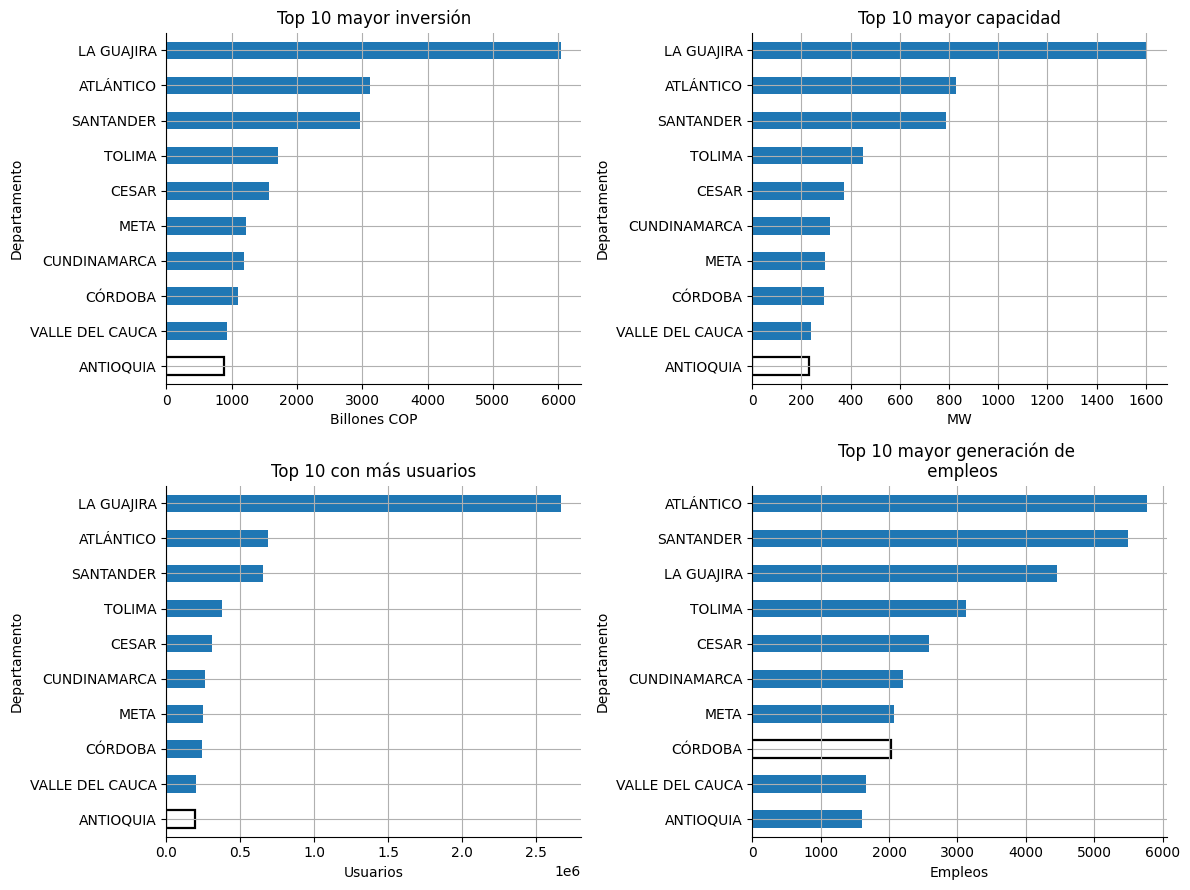

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

DEP_ATIPICO = "LA GUAJIRA"

g_cap = df.groupby("Departamento")["Capacidad"].sum().sort_values(ascending=False)
g_inv = df.groupby("Departamento")["Inversión estimada [COP]"].sum().sort_values(ascending=False)
g_usu = df.groupby("Departamento")["Usuarios"].sum().sort_values(ascending=False)
g_emp = df.groupby("Departamento")["Empleos estimados"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(2,2, figsize=(12,9))
for ax, serie, titulo, unidad in [
    (axes[0,0], g_inv.head(10)/1e9, "Top 10 mayor inversión", "Billones COP"),
    (axes[0,1], g_cap.head(10),     "Top 10 mayor capacidad", "MW"),
    (axes[1,0], g_usu.head(10),     "Top 10 con más usuarios",  "Usuarios"),
    (axes[1,1], g_emp.head(10),     "Top 10 mayor generación de \n empleos",   "Empleos")
]:
    serie.sort_values().plot(kind="barh", ax=ax)
    ax.set_title(titulo); ax.set_xlabel(unidad)
    for i, d in enumerate(serie.index):
        if d == DEP_ATIPICO:
            ax.get_children()[i].set_edgecolor("black")
            ax.get_children()[i].set_linewidth(1.6)
            ax.get_children()[i].set_fill(False)
plt.tight_layout(); plt.show()


# Los Top 10 confirman una fuerte concentración regional.

- La Guajira lidera ampliamente en inversión, capacidad y usuarios, consolidándose como el epicentro de la transición energética.

- Atlántico y Santander aparecen como segundos polos relevantes, especialmente en empleo, donde Atlántico incluso supera a La Guajira.

- Departamentos como Tolima, Cesar, Meta y Cundinamarca muestran una presencia intermedia pero sostenida en los cuatro indicadores.

- Finalmente, regiones como Antioquia y Valle del Cauca logran entrar en el top, aunque con valores mucho menores frente al liderazgo de La Guajira.



/tmp/ipykernel_148/4237816900.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=15)


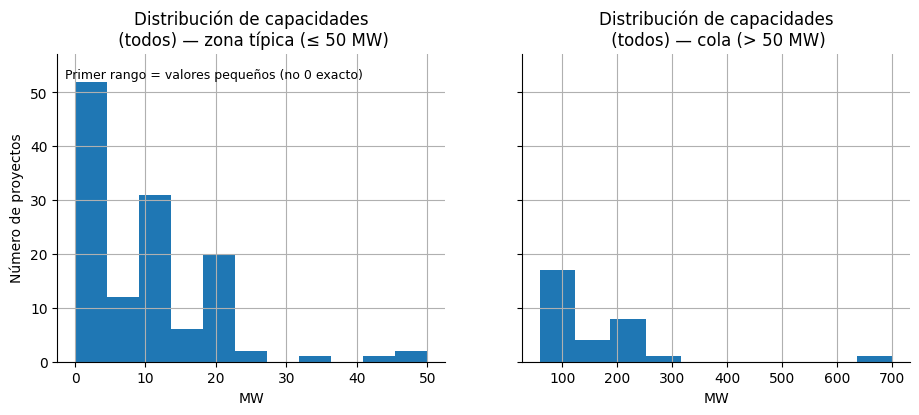

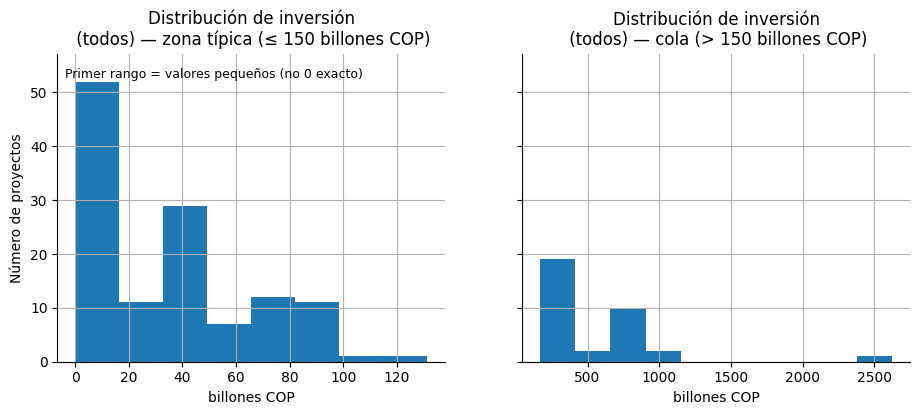

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def hist_dos_ventanas(data, titulo, unidad, umbral_zoom_izq):
    data = np.asarray(data.dropna())
    left = data[data <= umbral_zoom_izq]
    right = data[data >  umbral_zoom_izq]

    # Bins automáticos pero con rangos explícitos para cada panel
    bins_left  = np.histogram_bin_edges(left,  bins="auto", range=(0, max(left.max(), 1e-9)))
    bins_right = np.histogram_bin_edges(right, bins="auto", range=(right.min(), data.max())) if len(right)>0 else np.array([0,1])

    # Para igualar la altura (y) comparamos máximos de conteos
    cL, _ = np.histogram(left,  bins=bins_left)
    cR, _ = np.histogram(right, bins=bins_right) if len(right)>0 else (np.array([0]), None)
    ymax = max(cL.max() if len(cL) else 0, cR.max() if len(cR) else 0) * 1.10

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,4), sharey=True)
    ax1.hist(left,  bins=bins_left)
    ax2.hist(right, bins=bins_right) if len(right)>0 else None

    ax1.set_ylim(0, ymax); ax2.set_ylim(0, ymax)
    ax1.set_title(f"{titulo} — zona típica (≤ {umbral_zoom_izq:g} {unidad})")
    ax2.set_title(f"{titulo} — cola (> {umbral_zoom_izq:g} {unidad})")

    ax1.set_xlabel(unidad); ax2.set_xlabel(unidad)
    ax1.set_ylabel("Número de proyectos")

    # Aclaración de la lectura
    ax1.text(0.02, 0.92, "Primer rango = valores pequeños (no 0 exacto)", transform=ax1.transAxes, fontsize=9)

    plt.tight_layout(pad=15)

    plt.show()

# Definimos las variables 'caps' e 'invb'
caps = df["Capacidad"]
invb = df["Inversión estimada [COP]"] / 1e9 # Convertir a billones

# Uso (elige un umbral razonable para separar cabeza/cola)
hist_dos_ventanas(caps, "Distribución de capacidades\n (todos)", "MW", umbral_zoom_izq=50)
hist_dos_ventanas(invb, "Distribución de inversión\n (todos)", "billones COP", umbral_zoom_izq=150)


## 5. Proyectos por año (desde 2015), separando **La Guajira**
Contamos proyectos por año a partir de 2015 y mostramos a La Guajira como **serie aparte**.


¿Qué significan 5.999,52 MW en la vida real?


1 MW = 1.000 kW → por día, 5.999,52 MW ≈ 143.988.480 kWh.

Consumo promedio simple ≈ 1,25 kWh por persona/día.

Equivale a abastecer ≈115.190.784 personas/día (más del doble de Colombia).

La Guajira (1.605,27 MW): ≈ 38.526.480 kWh/día → ≈30,8 millones de personas/día.

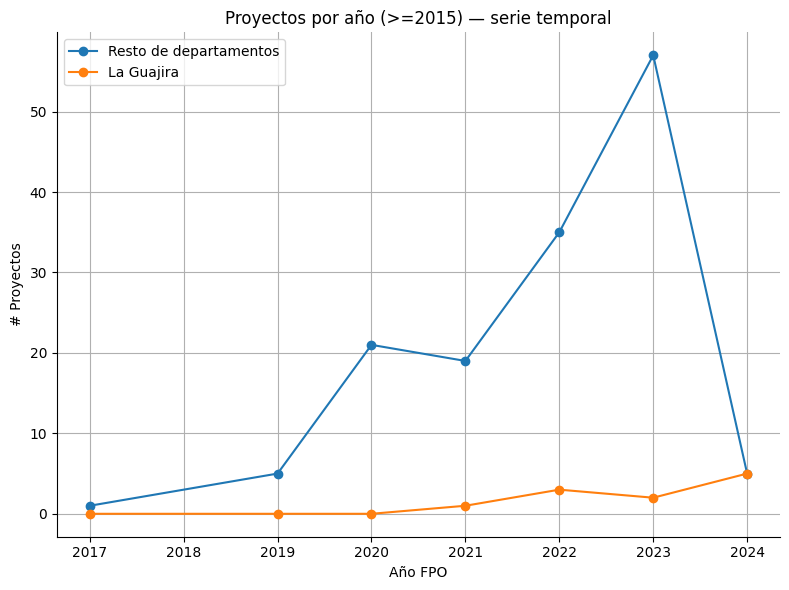

In [ ]:
df_year = df[df["Año FPO"] >= 2015].copy()

DEP_ATIPICO = "LA GUAJIRA"
solo_gua = df_year[df_year["Departamento"].str.upper() == DEP_ATIPICO]
resto    = df_year[df_year["Departamento"].str.upper() != DEP_ATIPICO]

g_rest = resto.groupby("Año FPO")["Proyecto"].count()
g_gua  = solo_gua.groupby("Año FPO")["Proyecto"].count()

years = sorted(set(g_rest.index).union(g_gua.index))
y_rest = [g_rest.get(y, 0) for y in years]
y_gua  = [g_gua.get(y, 0) for y in years]

fig, ax = plt.subplots()
ax.plot(years, y_rest, marker="o", label="Resto de departamentos")
ax.plot(years, y_gua,  marker="o", label="La Guajira")
ax.set_title("Proyectos por año (>=2015) — serie temporal")
ax.set_xlabel("Año FPO"); ax.set_ylabel("# Proyectos")
ax.legend()
plt.tight_layout(); plt.show()


## 6. Capacidad por departamento y tipo
Sumamos MW por `Departamento` y `Tipo` y usamos barras apiladas. La Guajira queda separada al **final** para facilitar la lectura comparativa.


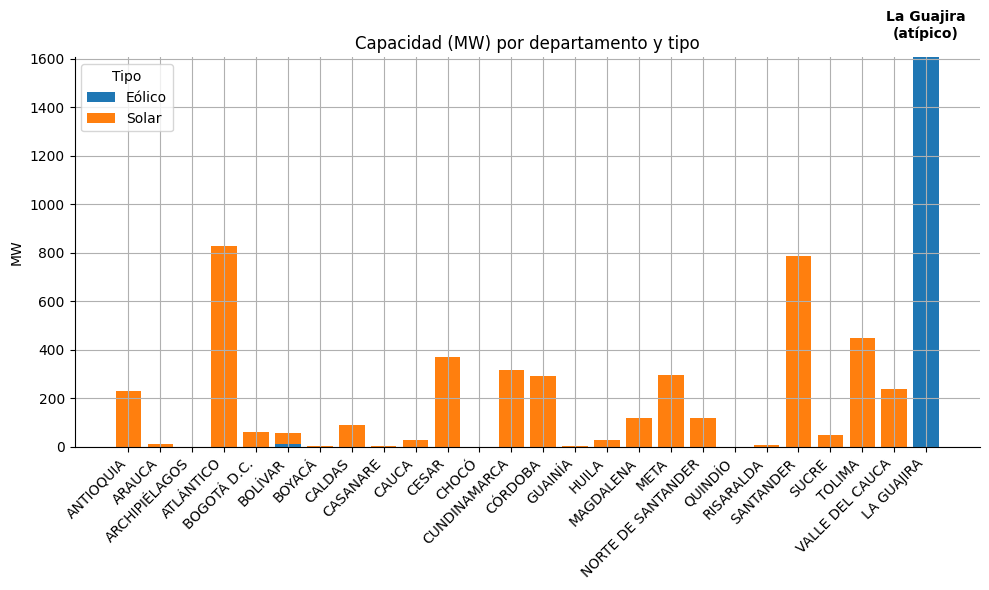

In [ ]:
agg = df.groupby(["Departamento","Tipo"], as_index=False)["Capacidad"].sum()

# Orden de departamentos: primero todos menos La Guajira, luego La Guajira
deps = [d for d in agg["Departamento"].unique() if d != DEP_ATIPICO]
deps = sorted(deps) + [DEP_ATIPICO]

tipos = sorted(df["Tipo"].dropna().unique().tolist())
pivot = agg.pivot(index="Departamento", columns="Tipo", values="Capacidad").reindex(deps).fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(pivot))
x = np.arange(len(pivot.index))
for t in tipos:
    vals = pivot[t].values if t in pivot.columns else np.zeros(len(pivot))
    ax.bar(x, vals, bottom=bottom, label=t)
    bottom += vals

ax.set_xticks(x, pivot.index, rotation=45, ha="right")
ax.set_title("Capacidad (MW) por departamento y tipo")
ax.set_ylabel("MW")
ax.legend(title="Tipo")

# Anotar La Guajira
lg_idx = list(pivot.index).index(DEP_ATIPICO)
ax.annotate("La Guajira\n(atípico)",
            xy=(lg_idx, bottom[lg_idx]), xytext=(0, 12),
            textcoords="offset points", ha="center", va="bottom", fontweight="bold")

plt.tight_layout(); plt.show()

## 7. Dispersión con leyendas: *Capacidad vs Inversión* y *Empleos vs Emisiones*
Señalamos La Guajira con marcador más grande y etiqueta. Los colores representan el `Tipo`.


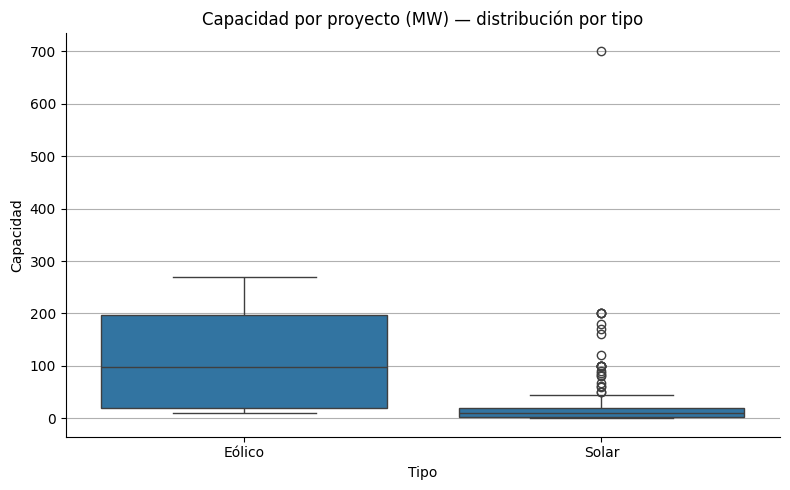

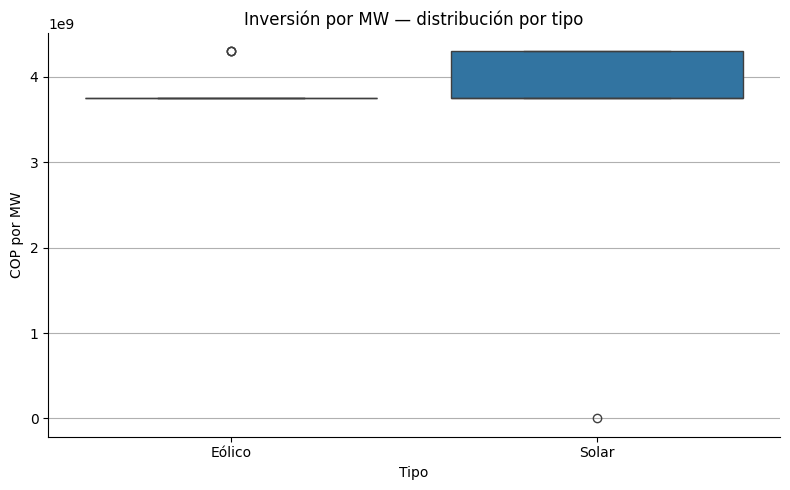

In [ ]:
import seaborn as sns

df_cmp = df.dropna(subset=["Capacidad","Inversión estimada [COP]","Tipo"]).copy()
df_cmp["Inv_bill"] = df_cmp["Inversión estimada [COP]"]/1e9
df_cmp["COP_por_MW"] = df_cmp["Inversión estimada [COP]"]/df_cmp["Capacidad"]

fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df_cmp, x="Tipo", y="Capacidad", ax=ax)
ax.set_title("Capacidad por proyecto (MW) — distribución por tipo")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df_cmp, x="Tipo", y="COP_por_MW", ax=ax)
ax.set_title("Inversión por MW — distribución por tipo")
ax.set_ylabel("COP por MW")
plt.tight_layout(); plt.show()


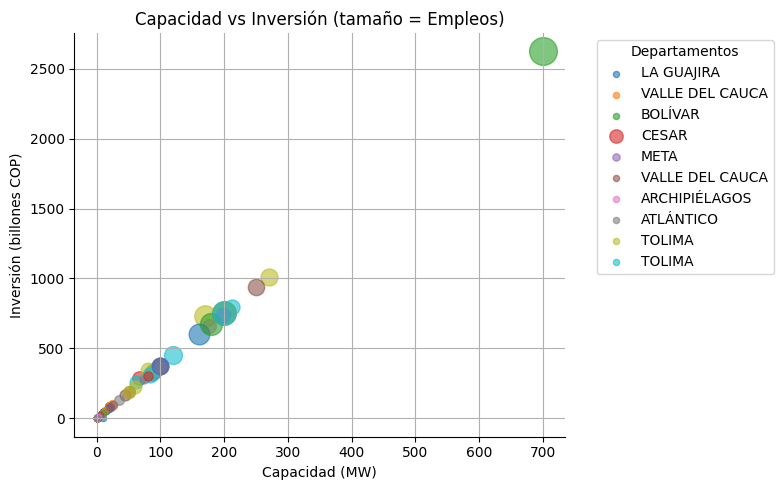

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

for _, row in df_cmp.iterrows():
    ax.scatter(row["Capacidad"], row["Inv_bill"],
               s=np.clip(row["Empleos estimados"]/5.0, 20, 400),
               alpha=0.6,
               label=row["Departamento"])

ax.set_title("Capacidad vs Inversión (tamaño = Empleos)")
ax.set_xlabel("Capacidad (MW)")
ax.set_ylabel("Inversión (billones COP)")

# Obtener todos los handles/labels creados
handles, labels = ax.get_legend_handles_labels()

# Mostrar solo los primeros 10
ax.legend(handles[:10], labels[:10],
          bbox_to_anchor=(1.05, 1), loc="upper left", title="Departamentos")

plt.tight_layout()
plt.show()

Capacidad total (MW) por departamento

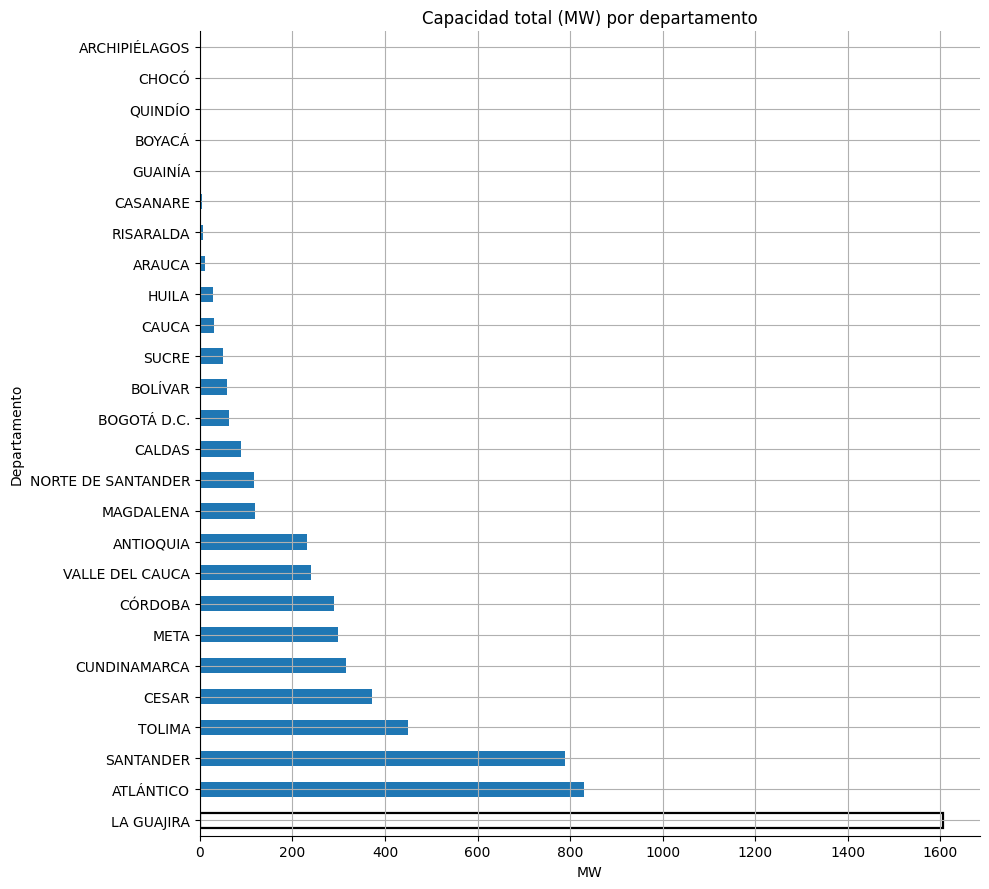

In [ ]:
g = df.groupby("Departamento")["Capacidad"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10,9))
g.plot(kind="barh", ax=ax, title="Capacidad total (MW) por departamento")
ax.set_xlabel("MW");
# Resalta La Guajira
if DEP_ATIPICO in g.index:
    idx = g.index.tolist().index(DEP_ATIPICO)
    ax.get_children()[idx].set_edgecolor("black"); ax.get_children()[idx].set_linewidth(1.6); ax.get_children()[idx].set_fill(False)
plt.tight_layout(); plt.show()


Usuarios beneficiados por departamento

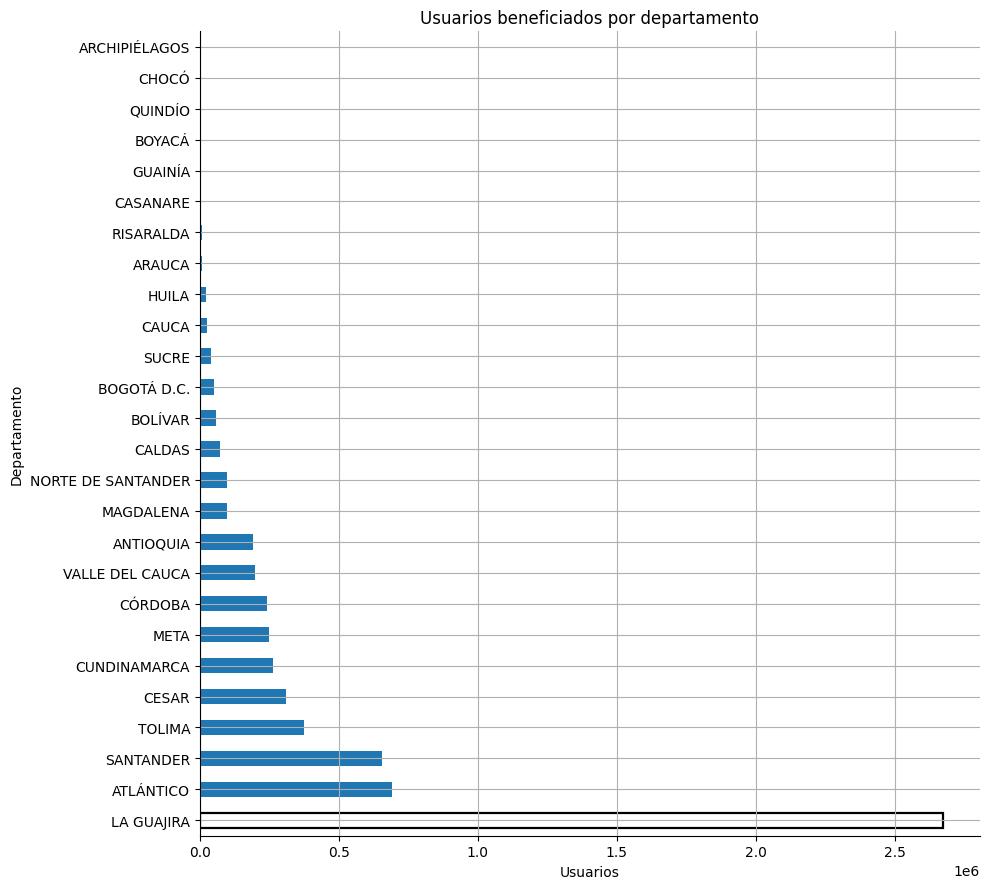

In [ ]:
g = df.groupby("Departamento")["Usuarios"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10,9))
g.plot(kind="barh", ax=ax, title="Usuarios beneficiados por departamento")
ax.set_xlabel("Usuarios")
if DEP_ATIPICO in g.index:
    idx = g.index.tolist().index(DEP_ATIPICO)
    ax.get_children()[idx].set_edgecolor("black"); ax.get_children()[idx].set_linewidth(1.6); ax.get_children()[idx].set_fill(False)
plt.tight_layout(); plt.show()


## 9. Coherencia rápida: Inversión por MW
Calculamos **COP por MW** para ver valores atípicos. Mostramos barras por departamento con La Guajira anotada.


Empleos estimados por departamento

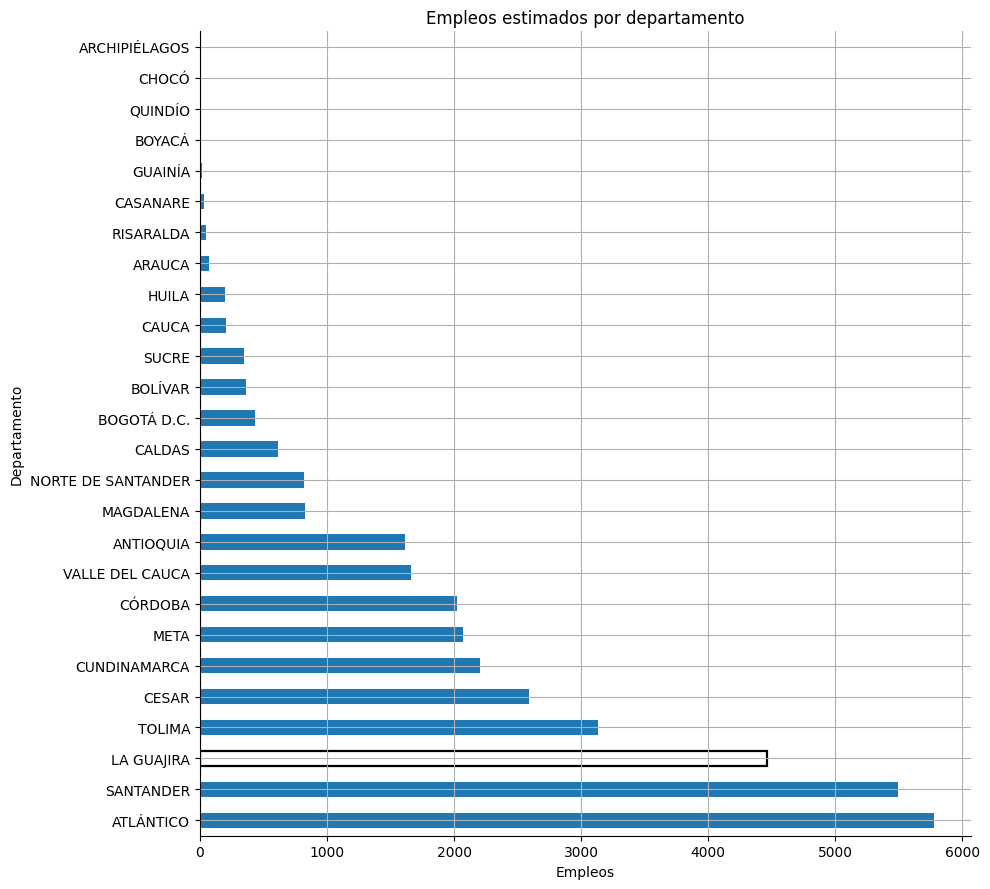

In [ ]:
g = df.groupby("Departamento")["Empleos estimados"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10,9))
g.plot(kind="barh", ax=ax, title="Empleos estimados por departamento")
ax.set_xlabel("Empleos")
if DEP_ATIPICO in g.index:
    idx = g.index.tolist().index(DEP_ATIPICO)
    ax.get_children()[idx].set_edgecolor("black"); ax.get_children()[idx].set_linewidth(1.6); ax.get_children()[idx].set_fill(False)
plt.tight_layout(); plt.show()


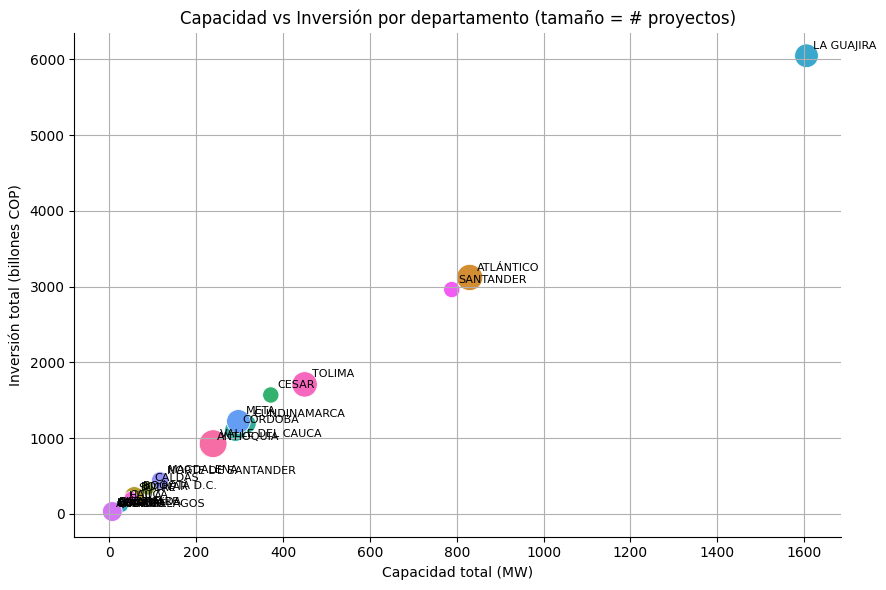

In [ ]:
# Agregado por departamento
dep_agg = (df.groupby("Departamento")
             .agg(Capacidad_total=("Capacidad","sum"),
                  Inversion_total=("Inversión estimada [COP]","sum"),
                  Proyectos=("Proyecto","count"))
             .reset_index())
dep_agg["Inversion_billones"] = dep_agg["Inversion_total"]/1e9

fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(data=dep_agg, x="Capacidad_total", y="Inversion_billones",
                size="Proyectos", sizes=(50,400), hue="Departamento", legend=False, ax=ax)

# Etiquetas (todas, o limita a top N para no saturar)
for _, r in dep_agg.iterrows():
    ax.annotate(r["Departamento"], xy=(r["Capacidad_total"], r["Inversion_billones"]),
                xytext=(5,5), textcoords="offset points", fontsize=8)

ax.set_title("Capacidad vs Inversión por departamento (tamaño = # proyectos)")
ax.set_xlabel("Capacidad total (MW)")
ax.set_ylabel("Inversión total (billones COP)")
plt.tight_layout(); plt.show()


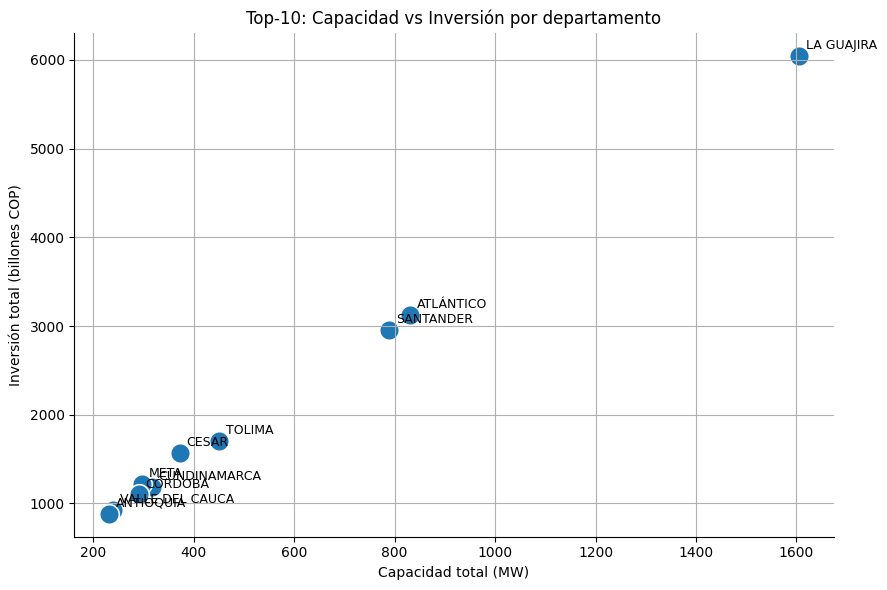

In [ ]:
top10 = dep_agg.sort_values("Capacidad_total", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9,6))
sns.scatterplot(data=top10, x="Capacidad_total", y="Inversion_billones", s=200, ax=ax)
for _, r in top10.iterrows():
    ax.annotate(r["Departamento"], (r["Capacidad_total"], r["Inversion_billones"]),
                xytext=(5,5), textcoords="offset points", fontsize=9)
ax.set_title("Top-10: Capacidad vs Inversión por departamento")
ax.set_xlabel("Capacidad total (MW)")
ax.set_ylabel("Inversión total (billones COP)")
plt.tight_layout(); plt.show()


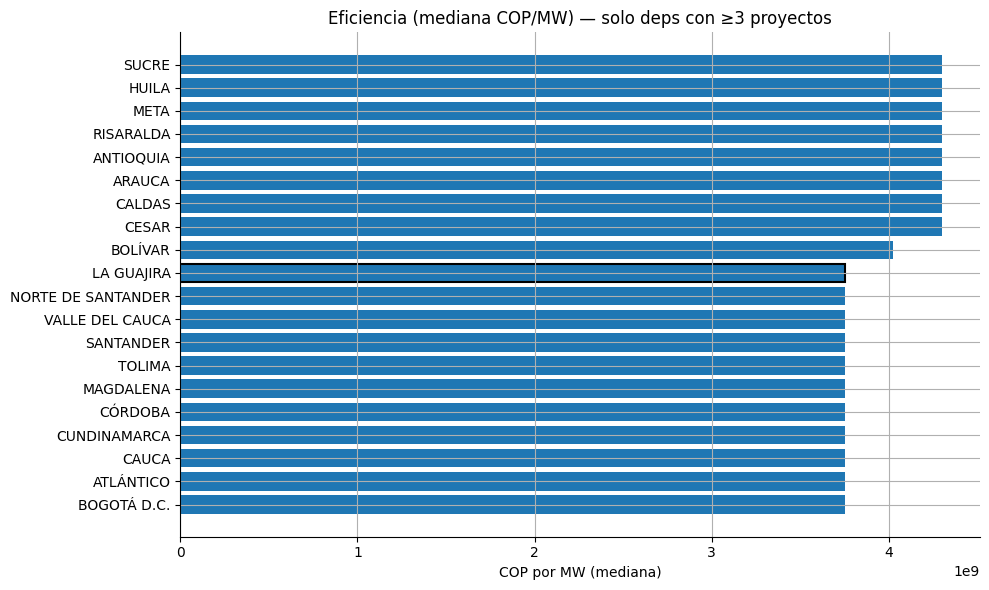

In [ ]:
df_ic = df.dropna(subset=["Inversión estimada [COP]","Capacidad"]).copy()
df_ic["COP_por_MW"] = df_ic["Inversión estimada [COP]"] / df_ic["Capacidad"]
counts = df_ic.groupby("Departamento")["COP_por_MW"].size()
valid_deps = counts[counts >= 3].index

rank = (df_ic[df_ic["Departamento"].isin(valid_deps)]
        .groupby("Departamento")["COP_por_MW"].median()
        .sort_values())

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(rank.index, rank.values)
ax.set_title("Eficiencia (mediana COP/MW) — solo deps con ≥3 proyectos")
ax.set_xlabel("COP por MW (mediana)")
# Resaltar La Guajira si está en el set validado
if DEP_ATIPICO in rank.index:
    ax.barh(DEP_ATIPICO, rank.loc[DEP_ATIPICO], edgecolor="k", linewidth=1.5, fill=False)
plt.tight_layout(); plt.show()


,# Proyectos,Capacidad,Usuarios,Empleos estimados
Alcance,,,,
Autoconsumo,90,410.46,348886.0,2817.0
Masivo,68,5589.06,5988346.0,32197.0


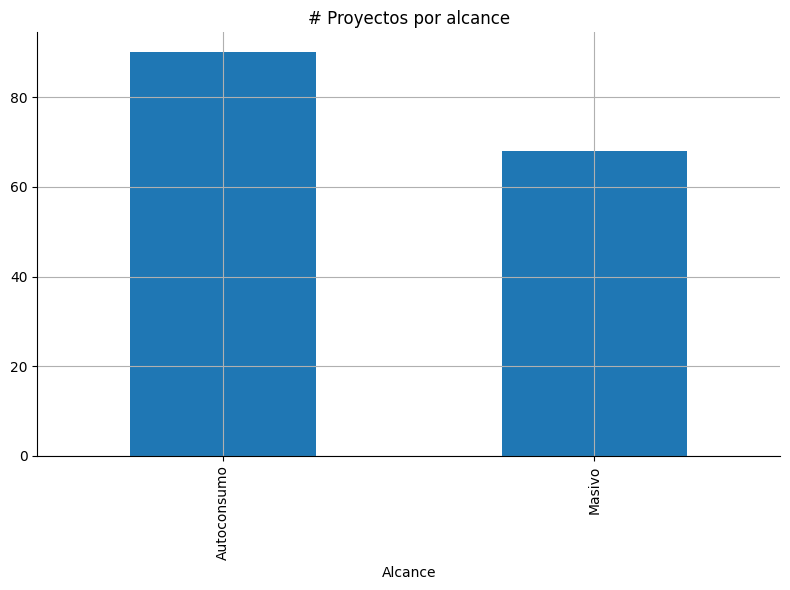

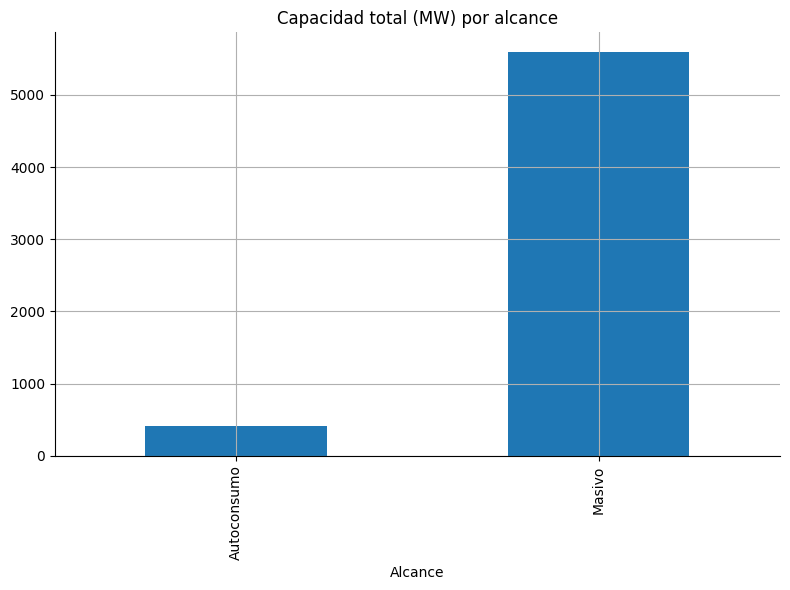

In [ ]:
# Regla simple (ajusta el umbral si tus profes piden otro criterio)
UMBRAL_MW_AUTOCONSUMO = 10
df_scope = df.copy()
df_scope["Alcance"] = np.where(df_scope["Capacidad"] <= UMBRAL_MW_AUTOCONSUMO, "Autoconsumo", "Masivo")

# Resumen y barras
res = (df_scope.groupby("Alcance")[["Proyecto","Capacidad","Usuarios","Empleos estimados"]]
       .agg({"Proyecto":"count","Capacidad":"sum","Usuarios":"sum","Empleos estimados":"sum"})
       .rename(columns={"Proyecto":"# Proyectos"}))
display(res)

fig, ax = plt.subplots()
(res["# Proyectos"]).plot(kind="bar", ax=ax, title="# Proyectos por alcance")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots()
(res["Capacidad"]).plot(kind="bar", ax=ax, title="Capacidad total (MW) por alcance")
plt.tight_layout(); plt.show()


Definimos Autoconsumo como proyectos con Capacidad ≤ 5 MW (regla operativa simple; ajustable). Masivo son los demás. Esta clasificación es aproximada y sirve para distinguir proyectos orientados a pocos usuarios de los que abastecen a más población o industria.

## 10. Emisiones evitadas netas (estimación simple)
Sumamos `Emisiones CO2 [Ton/año]` por departamento y comparamos con la capacidad total para detectar outliers. La Guajira se etiqueta explícitamente.


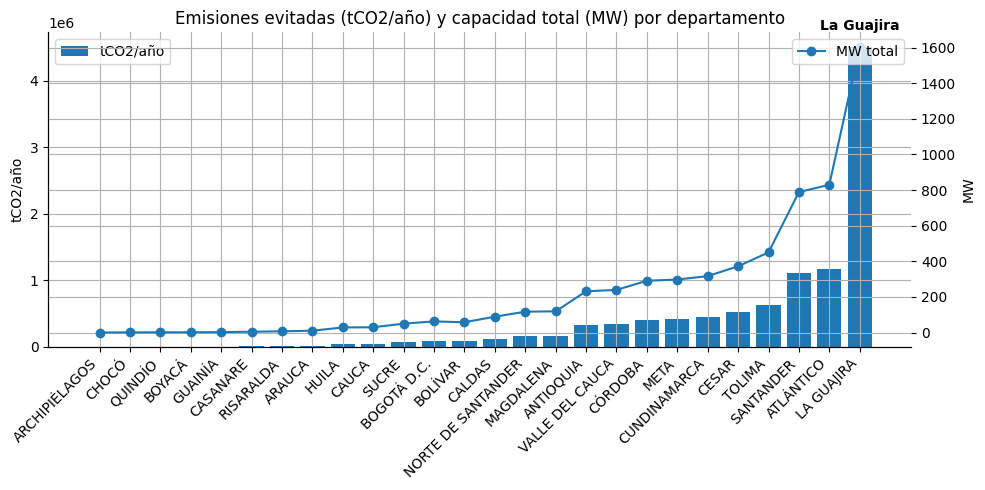

In [ ]:
g_e = df.groupby("Departamento")["Emisiones CO2 [Ton/año]"].sum().rename("tCO2_año")
g_c = df.groupby("Departamento")["Capacidad"].sum().rename("MW_total")
mix = pd.concat([g_e, g_c], axis=1).fillna(0).sort_values("tCO2_año")

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(mix.index))
ax.bar(x, mix["tCO2_año"].values, label="tCO2/año")
ax2 = ax.twinx()
ax2.plot(x, mix["MW_total"].values, marker="o", label="MW total")

ax.set_xticks(x, mix.index, rotation=45, ha="right")
ax.set_title("Emisiones evitadas (tCO2/año) y capacidad total (MW) por departamento")
ax.set_ylabel("tCO2/año"); ax2.set_ylabel("MW")
ax.legend(loc="upper left"); ax2.legend(loc="upper right")

if DEP_ATIPICO in mix.index:
    idx = mix.index.tolist().index(DEP_ATIPICO)
    ax.annotate("La Guajira", xy=(idx, mix.loc[DEP_ATIPICO, "tCO2_año"]), xytext=(0, 10),
                textcoords="offset points", ha="center", va="bottom", fontweight="bold")
plt.tight_layout(); plt.show()

In [ ]:
import numpy as np

UMBRAL_MW_AUTOCONSUMO = 5.0

df_scope = df.copy()
df_scope["Alcance"] = np.where(df_scope["Capacidad"] <= UMBRAL_MW_AUTOCONSUMO, "Autoconsumo", "Masivo")

# Capacidad por alcance
cap_por_alcance = (df_scope
                   .pivot_table(index="Departamento", columns="Alcance",
                                values="Capacidad", aggfunc="sum", fill_value=0)
                   .rename_axis(None, axis=1))

# Inversión total y eficiencia (mediana COP/MW por dep.)
eff = (df_scope.dropna(subset=["Capacidad","Inversión estimada [COP]"])
               .assign(COP_por_MW=lambda x: x["Inversión estimada [COP]"]/x["Capacidad"])
               .groupby("Departamento")["COP_por_MW"].median())

inv_total = df_scope.groupby("Departamento")["Inversión estimada [COP]"].sum()
cap_total = df_scope.groupby("Departamento")["Capacidad"].sum()

tabla = (pd.concat([
            inv_total.rename("Inversión total (COP)"),
            cap_total.rename("Capacidad total (MW)"),
            cap_por_alcance.get("Autoconsumo", pd.Series(dtype=float)).rename("Capacidad Autoconsumo (MW)"),
            cap_por_alcance.get("Masivo", pd.Series(dtype=float)).rename("Capacidad Masivo (MW)"),
            eff.rename("Mediana COP/MW")
        ], axis=1)
        .fillna(0)
        .sort_values("Capacidad total (MW)", ascending=False))

# Columna en billones para lectura rápida
tabla["Inversión (billones)"] = tabla["Inversión total (COP)"]/1e9

display(tabla.head(15))


,Inversión total (COP),Capacidad total (MW),Capacidad Autoconsumo (MW),Capacidad Masivo (MW),Mediana COP/MW,Inversión (billones)
Departamento,,,,,,
LA GUAJIRA,6.047440e+12,1605.27,0.00,1605.27,3.750001e+09,6047.4400
ATLÁNTICO,3.120237e+12,829.74,3.74,826.00,3.750000e+09,3120.2370
SANTANDER,2.960622e+12,788.54,1.30,787.24,3.750000e+09,2960.6220
TOLIMA,1.708612e+12,449.81,0.08,449.73,3.750000e+09,1708.6115
CESAR,1.568975e+12,371.90,0.00,371.90,4.300000e+09,1568.9750
CUNDINAMARCA,1.187475e+12,316.66,16.66,300.00,3.750000e+09,1187.4750
META,1.219915e+12,297.40,1.90,295.50,4.300000e+09,1219.9150
CÓRDOBA,1.100714e+12,290.63,1.50,289.13,3.750000e+09,1100.7140
VALLE DEL CAUCA,9.263715e+11,239.13,11.32,227.81,3.750000e+09,926.3715


In [ ]:
top_proj_cap = df[["Proyecto","Departamento","Capacidad"]].sort_values("Capacidad", ascending=False).head(10)
top_proj_inv = df[["Proyecto","Departamento","Inversión estimada [COP]"]].sort_values("Inversión estimada [COP]", ascending=False).head(10)

print("Top 10 proyectos por Capacidad (MW):")
print(top_proj_cap.to_string(index=False))

print("\nTop 10 proyectos por Inversión (COP):")
print(top_proj_inv.to_string(index=False))


Top 10 proyectos por Capacidad (MW):
                   Proyecto Departamento  Capacidad
                 SEBASTOSOL    SANTANDER     700.00
               BETHA (EDPR)   LA GUAJIRA     270.00
           CAMELIA (CELSIA)   LA GUAJIRA     250.00
               ALPHA (EDPR)   LA GUAJIRA     212.00
             GUAYEPO FASE I    ATLÁNTICO     200.00
                     SIERRA    ANTIOQUIA     200.00
            GUAYEPO FASE II    ATLÁNTICO     200.00
                SABANALARGA    ATLÁNTICO     200.00
TUMAWIND (ENEL GREEN POWER)   LA GUAJIRA     197.77
                  WINDPESHI   LA GUAJIRA     195.03

Top 10 proyectos por Inversión (COP):
                   Proyecto Departamento  Inversión estimada [COP]
                 SEBASTOSOL    SANTANDER              2.625000e+12
               BETHA (EDPR)   LA GUAJIRA              1.012500e+12
           CAMELIA (CELSIA)   LA GUAJIRA              9.375000e+11
               ALPHA (EDPR)   LA GUAJIRA              7.950000e+11
             GUAY

### Conclusiones
- **Concentración**: Pocos departamentos concentran gran parte de la **capacidad** e **inversión**; La Guajira destaca por escala.
- **Alcance**: Con la regla operacional (≤10 MW autoconsumo), identificamos la fracción del portafolio orientada a **pocos usuarios** vs **masivo**.
- **Eficiencia**: La **mediana COP/MW** por departamento ayuda a ver dónde la inversión rinde más capacidad (evita sesgos por outliers).
- **Lectura para público general**: Evitamos transformaciones log y “heatmaps normalizados”; priorizamos **gráficas simples** + **tablas** para casos extremos.
